In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')


ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Constants
TICKER = "TCS.NS"
WINDOW_SIZE = 60 # Look back 60 days to predict the next day

# Set path (assumes you are in notebooks/ folder)
csv_path = f"data/{TICKER.replace('.','_')}_raw.csv"

if not os.path.exists(csv_path):
    # Fallback to root data folder if needed
    csv_path = f"../data/{TICKER.replace('.','_')}_raw.csv"

print(f"Loading data from: {csv_path}")
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# Use 'Close' price only
data = df[['Close']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Data loaded. Total records: {len(scaled_data)}")


Loading data from: data/TCS_NS_raw.csv
Data loaded. Total records: 1726


In [ ]:
# --- Create Sequences (Sliding Window) ---
# We need to recreate X_train and X_test since we are in a new notebook

WINDOW_SIZE = 60

def create_sequences(dataset, window):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i-window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Train/Test Split (80/20)
split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape for LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [ ]:
# --- Step 1: Verify input shapes (from Phase 2 preprocessing) ---
# These variables come from your preprocessing phase

print("=== Input Shape Verification ===")
print(f"X_train : {X_train.shape}  → (samples, timesteps, features)")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
# Expected: X_train = (N, 60, 1)

=== Input Shape Verification ===
X_train : (1332, 60, 1)  → (samples, timesteps, features)
X_test  : (334, 60, 1)
y_train : (1332,)
y_test  : (334,)


In [ ]:
# --- Step 2: Build stacked LSTM model ---
model = Sequential([

    # First LSTM layer — return_sequences=True passes output to next LSTM
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),      # drops 20% neurons randomly to prevent overfitting

    # Second LSTM layer
    LSTM(64, return_sequences=False),
    Dropout(0.2),

    # Dense layers for final prediction
    Dense(32, activation='relu'),
    Dense(1)           # single output — next day's price (scaled)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Step 3: Set up callbacks ---
import os
os.makedirs("models", exist_ok=True)

# Stop training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Save best model automatically
checkpoint = ModelCheckpoint(
    filepath='models/lstm_best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
# --- Step 4: Train the model ---
print("Training LSTM model...")

history_log = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,     # 10% of train used for validation
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history_log.history['loss'])}")

Training LSTM model...
Epoch 1/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0743
Epoch 1: val_loss improved from None to 0.00122, saving model to models/lstm_best_model.h5



Epoch 1: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0270 - val_loss: 0.0012
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0026
Epoch 2: val_loss improved from 0.00122 to 0.00057, saving model to models/lstm_best_model.h5



Epoch 2: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0024 - val_loss: 5.6719e-04
Epoch 3/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0021
Epoch 3: val_loss improved from 0.00057 to 0.00056, saving model to models/lstm_best_model.h5



Epoch 3: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0021 - val_loss: 5.6070e-04
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0020
Epoch 4: val_loss did not improve from 0.00056
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 6.1942e-04
Epoch 5/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0020
Epoch 5: val_loss improved from 0.00056 to 0.00052, saving model to models/lstm_best_model.h5



Epoch 5: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0017 - val_loss: 5.1785e-04
Epoch 6/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017
Epoch 6: val_loss did not improve from 0.00052
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0018 - val_loss: 6.9997e-04
Epoch 7/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0017
Epoch 7: val_loss did not improve from 0.00052
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0014
Epoch 8: val_loss did not improve from 0.00052
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - val_loss: 6.1745e-04
Epoch 9/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0015
Epoch 9: val_loss did not improve from 0.00052
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012
Epoch 10: val_loss did not improv

...


Epoch 23: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.6867e-04 - val_loss: 3.2406e-04
Epoch 24/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.5039e-04
Epoch 24: val_loss did not improve from 0.00032
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 8.9387e-04 - val_loss: 7.5682e-04
Epoch 25/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.0191e-04
Epoch 25: val_loss did not improve from 0.00032
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 8.7577e-04 - val_loss: 6.1988e-04
Epoch 26/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 7.9549e-04
Epoch 26: val_loss did not improve from 0.00032
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.0976e-04 - val_loss: 0.0011
Epoch 27/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.0974e-04
Epoch 27: val_loss did not improve from 0.00032
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.1096e-04 - val_loss: 6.0012e-04
Epoch 28/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


Epoch 31: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7.0764e-04 - val_loss: 2.9482e-04
Epoch 32/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.1947e-04
Epoch 32: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7.7930e-04 - val_loss: 3.8294e-04
Epoch 33/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.5423e-04
Epoch 33: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 7.3572e-04 - val_loss: 0.0011
Epoch 34/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 6.1715e-04
Epoch 34: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 6.5744e-04 - val_loss: 7.1704e-04
Epoch 35/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 6.8662e-04
Epoch 35: val_loss improved from 0.00029 to 0.00029, saving model to models/lstm_best_model.h5



Epoch 35: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 6.2025e-04 - val_loss: 2.9314e-04
Epoch 36/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7.1575e-04
Epoch 36: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.4131e-04 - val_loss: 0.0015
Epoch 37/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 7.1345e-04
Epoch 37: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 6.9273e-04 - val_loss: 4.8319e-04
Epoch 38/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7.1228e-04
Epoch 38: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 6.9293e-04 - val_loss: 3.3911e-04
Epoch 39/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.0907e-04
Epoch 39: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.9869e-04 - val_loss: 3.5291e-04
Epoch 40/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


Epoch 42: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 5.9069e-04 - val_loss: 2.9207e-04
Epoch 43/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.5547e-04
Epoch 43: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.6365e-04 - val_loss: 4.2658e-04
Epoch 44/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 5.9802e-04
Epoch 44: val_loss did not improve from 0.00029
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.4074e-04 - val_loss: 3.7009e-04
Epoch 45/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.0885e-04
Epoch 45: val_loss improved from 0.00029 to 0.00027, saving model to models/lstm_best_model.h5



Epoch 45: finished saving model to models/lstm_best_model.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.4759e-04 - val_loss: 2.6893e-04
Epoch 46/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 5.7728e-04
Epoch 46: val_loss did not improve from 0.00027
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.8089e-04 - val_loss: 3.1626e-04
Epoch 47/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.1917e-04
Epoch 47: val_loss did not improve from 0.00027
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 5.6638e-04 - val_loss: 4.1237e-04
Epoch 48/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.8274e-04
Epoch 48: val_loss did not improve from 0.00027
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.1177e-04 - val_loss: 2.9193e-04
Epoch 49/100
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 6.0701e-04
Epoch 49: val_loss did not improve from 0.00027
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 6.4942e-04 - val_loss: 3.1706e-04
Epoch 50/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/

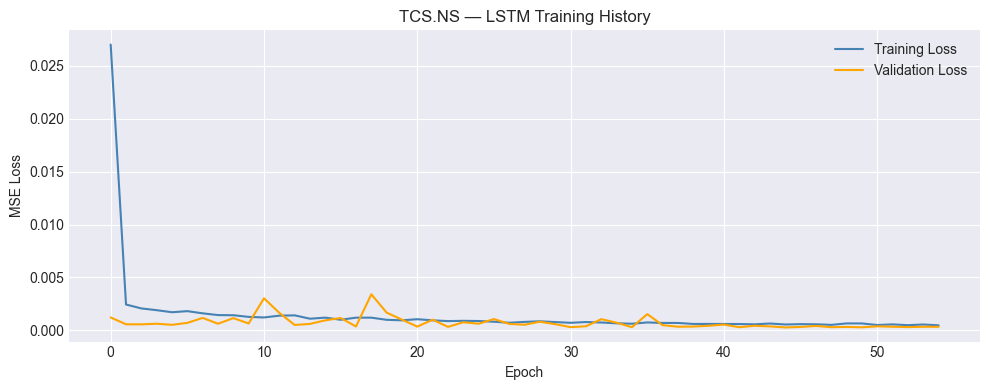

In [ ]:
# --- Step 5: Plot training vs validation loss ---
plt.figure(figsize=(10, 4))
plt.plot(history_log.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history_log.history['val_loss'], label='Validation Loss', color='orange')
plt.title(f'{TICKER} — LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('plots/09_lstm_training_loss.png', dpi=150)
plt.show()

In [ ]:
# --- Step 6: Predict on test data ---
lstm_preds_scaled = model.predict(X_test)

# Inverse transform — convert back from [0,1] to actual ₹ price
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
actual_lstm = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Prediction shape : {lstm_preds.shape}")
print(f"Sample predictions (₹): {lstm_preds[:5].flatten().round(2)}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Prediction shape : (334, 1)
Sample predictions (₹): [3190.25 3177.96 3165.08 3155.66 3148.16]


In [ ]:
# --- Step 7: Evaluate LSTM ---
mae  = mean_absolute_error(actual_lstm, lstm_preds)
rmse = np.sqrt(mean_squared_error(actual_lstm, lstm_preds))
mape = np.mean(np.abs((actual_lstm - lstm_preds) / actual_lstm)) * 100

print("\n=== LSTM Performance ===")
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


=== LSTM Performance ===
MAE  : ₹101.70
RMSE : ₹128.86
MAPE : 2.64%


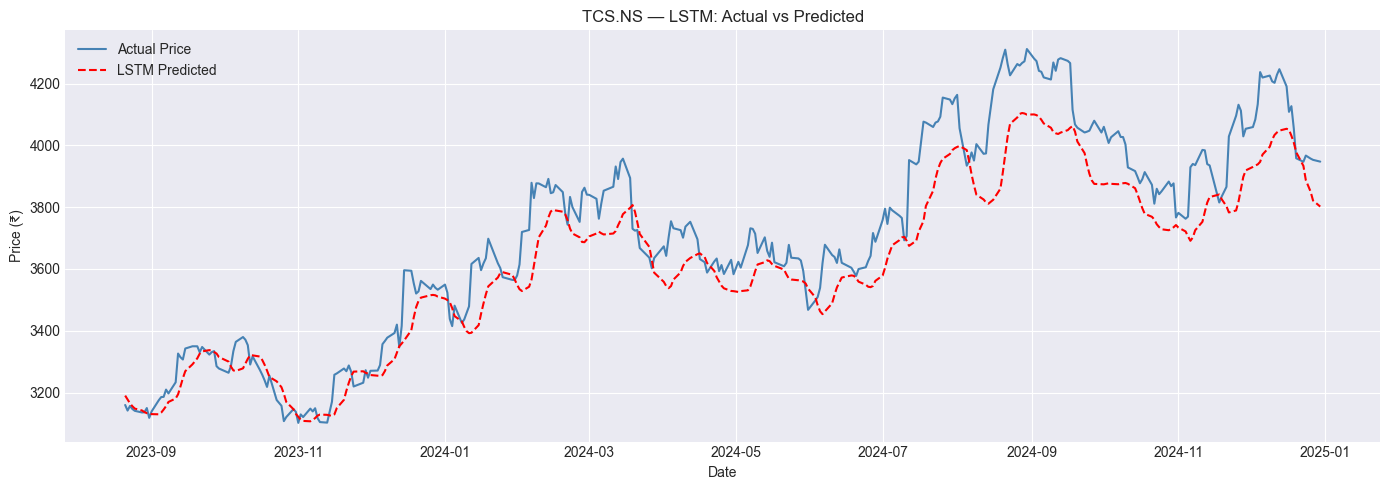

In [ ]:
# --- Step 8: Plot Actual vs Predicted ---
test_dates = df.index[split_idx + WINDOW_SIZE:]   # align dates with predictions

plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual_lstm, color='steelblue', label='Actual Price', linewidth=1.5)
plt.plot(test_dates, lstm_preds,  color='red', label='LSTM Predicted', linewidth=1.5, linestyle='--')
plt.title(f'{TICKER} — LSTM: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/10_lstm_prediction.png', dpi=150)
plt.show()


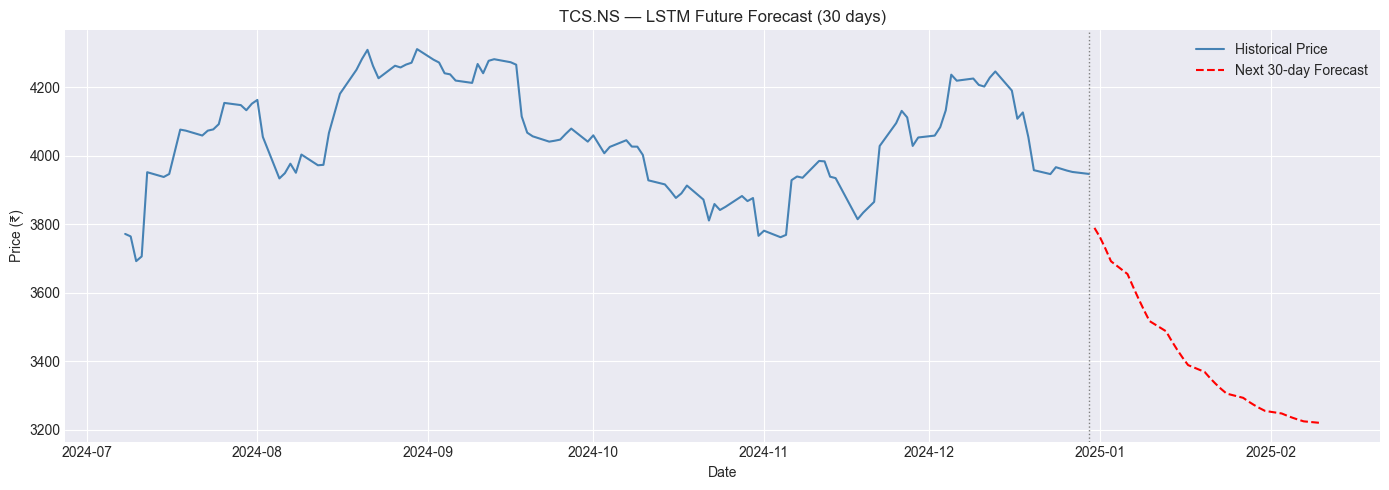

In [ ]:
# --- Step 9: Predict NEXT N days (future forecast) ---
FORECAST_DAYS = 30   # predict next 30 trading days

# Start from the last 60 days of full dataset
last_60 = scaler.transform(df[['Close']].values[-60:])
input_seq = list(last_60.flatten())

future_preds = []
for _ in range(FORECAST_DAYS):
    x = np.array(input_seq[-60:]).reshape(1, 60, 1)
    pred = model.predict(x, verbose=0)[0][0]
    future_preds.append(pred)
    input_seq.append(pred)

# Inverse transform future predictions
future_preds = scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)
)

# Create future date index (skip weekends)
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=FORECAST_DAYS + 1)[1:]

plt.figure(figsize=(14, 5))
plt.plot(df.index[-120:], df['Close'].values[-120:],
         color='steelblue', label='Historical Price')
plt.plot(future_dates, future_preds,
         color='red', linestyle='--', label=f'Next {FORECAST_DAYS}-day Forecast')
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1)
plt.title(f'{TICKER} — LSTM Future Forecast ({FORECAST_DAYS} days)')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/11_lstm_future_forecast.png', dpi=150)
plt.show()


In [ ]:
# --- Step 10: Save results for comparison ---
lstm_results = {
    'model' : 'LSTM (64+64 units)',
    'MAE'   : round(mae, 2),
    'RMSE'  : round(rmse, 2),
    'MAPE'  : round(mape, 2),
    'preds' : lstm_preds.flatten().tolist()
}
print("\nLSTM results saved. Ready for model comparison.")


LSTM results saved. Ready for model comparison.
